In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
# --- 0) Setup & imports ---
import os, sys, json
import numpy as np
from PIL import Image  # or imageio.v2
# If the package folder is next to the notebook; adjust if needed:
sys.path.append(".")

from src.retina_biomarkers import (
    to_bool_mask, skeletonize_mask, distance_transform, build_skeleton_graph,
    sample_width_along_skeleton, sample_widths_orthogonal,   # <-- NEW
    area_density, length_density, caliber_stats,
    tortuosity_stats, fractal_dimension_boxcount,
    junction_metrics, branching_and_bifurcation_angles,
    branching_angles_roi,                                    # <-- NEW
    gap_metrics, metrics_by_rings
)


In [3]:

# --- 1) I/O helper: load a binary mask from a path ---
def load_binary_mask(mask_path: str) -> np.ndarray:
    """
    Loads a 2D binary vessel mask (0/1 or 0/255).
    If the image has multiple channels, it converts to L (grayscale).
    Any positive value becomes vessel.
    """
    if not os.path.exists(mask_path):
        raise FileNotFoundError(mask_path)
    img = Image.open(mask_path)
    if img.mode != "L":
        img = img.convert("L")
    arr = np.array(img)          # uint8
    mask = (arr > 0).astype(np.uint8)
    return mask

# --- 2) Core: compute all metrics from a binary mask ---
def compute_biomarkers_from_mask_path(
    mask_path: str,
    *,
    disc_center=None,      # (y, x) in px
    PD_px=None,            # optic disc diameter in px
    max_gap_px: int = 10,
    angle_k_ahead: int = 3,
    ortho_step: float = 0.5,
    ortho_max_radius: float = 20.0
) -> dict:
    """Return a nested dict with global, topology, and (optional) ring metrics."""
    mask = load_binary_mask(mask_path)
    H, W = mask.shape

    # --- Geometry ---
    skel  = skeletonize_mask(mask)
    dist  = distance_transform(mask)
    graph = build_skeleton_graph(skel)

    # --- Calibre (two ways) ---
    widths_edt  = sample_width_along_skeleton(dist, graph)  # EDT-based width
    widths_orth = sample_widths_orthogonal(                 # paper-consistent, orthogonal chords
        mask, graph, k_tangent=3, step=ortho_step, max_radius=ortho_max_radius
    )

    # --- Global metrics ---
    ld_px_inv = float(length_density(graph, mask.shape))
    vc_edt  = caliber_stats(widths_edt)
    vc_orth = caliber_stats(widths_orth)

    global_metrics = {
        "area_density":          float(area_density(mask)),
        "length_density_px_inv": ld_px_inv,
        "fractal_dimension":     float(fractal_dimension_boxcount(skel)),
        **tortuosity_stats(graph),
        "vc_edt":  vc_edt,                    # keep for appendix
        "vc_orth": vc_orth,                   # use this in the paper
        # convenience (mirror orthogonal values to top-level)
        "median_width": vc_orth["median_width"],
        "iqr_width":    vc_orth["iqr_width"],
    }

    # --- PD normalization (only if PD_px provided) ---
    if PD_px is not None:
        global_metrics["median_width_PD"]      = global_metrics["median_width"] / PD_px
        global_metrics["iqr_width_PD"]         = global_metrics["iqr_width"]    / PD_px
        # length density scaled to PD units (helps cross-image comparability)
        global_metrics["length_density_PD_inv"] = ld_px_inv * (PD_px ** 2)

    # --- Topology & continuity ---
    topo = {}
    topo.update(junction_metrics(graph, mask.shape))
    topo.update(branching_and_bifurcation_angles(graph, k_ahead=angle_k_ahead))
    topo.update(gap_metrics(mask, graph, max_gap_px=max_gap_px))

    # Angles within 2 PD (paper-aligned)
    topo["angles_2PD"] = None
    if disc_center is not None and PD_px is not None:
        topo["angles_2PD"] = branching_angles_roi(
            graph, disc_center=disc_center, PD_px=PD_px, max_PD=2.0, k_ahead=angle_k_ahead
        )

    # --- Ring-wise metrics (0.5 PD steps; use orth widths to match paper) ---
    rings = None
    if disc_center is not None and PD_px is not None:
        rings = metrics_by_rings(
            mask, graph, widths_orth, disc_center=disc_center, PD_px=PD_px
        )

    return {
        "image_path": mask_path,
        "image_shape": (H, W),
        "global": global_metrics,
        "topology": topo,
        "rings": rings,  # None if not computed
    }

In [4]:
# --- 3) Example usage ---
# Replace with your actual mask path (PNG/TIF/JPG containing a binary vessel mask)
mask_path = "../../data/raw/DRIVE/test/1st_manual/01_manual1.png"

# If you know disc center and disc diameter in pixels, pass them; otherwise omit
# Example placeholders:
disc_center = (256, 256)  # example
PD_px = 100.0             # example (diameter in pixels)

results = compute_biomarkers_from_mask_path(
    mask_path,
    disc_center=disc_center,
    PD_px=PD_px,
    max_gap_px=12,
    angle_k_ahead=3
)


# Pretty-print / save
print(json.dumps(results, indent=2))
# with open("biomarkers.json", "w") as f: json.dump(results, f, indent=2)

{
  "image_path": "../../data/raw/DRIVE/test/1st_manual/01_manual1.png",
  "image_shape": [
    584,
    565
  ],
  "global": {
    "area_density": 0.08922293611346829,
    "length_density_px_inv": 0.03426140733438053,
    "fractal_dimension": 1.406667044447461,
    "tortuosity_mean": 0.16643938422203064,
    "vc_edt": {
      "median_width": 2.8284270763397217,
      "iqr_width": 2.0,
      "frac_thin_len": 0.7728292971057295,
      "frac_med_len": 0.21760189013585352,
      "frac_thick_len": 0.009568812758417011
    },
    "vc_orth": {
      "median_width": 4.0,
      "iqr_width": 4.0,
      "frac_thin_len": 0.5781692068996989,
      "frac_med_len": 0.29049922424021174,
      "frac_thick_len": 0.13133156886008945
    },
    "median_width": 4.0,
    "iqr_width": 4.0,
    "median_width_PD": 0.04,
    "iqr_width_PD": 0.04,
    "length_density_PD_inv": 342.61407334380533
  },
  "topology": {
    "junction_count": 714.0,
    "endpoint_count": 133.0,
    "junction_density": 0.0021638986543

In [5]:
# --- 3) Example usage ---
# Replace with your actual mask path (PNG/TIF/JPG containing a binary vessel mask)
mask_path = "../../data/raw/DRIVE/training/1st_manual/22_manual1.png"

# If you know disc center and disc diameter in pixels, pass them; otherwise omit
# Example placeholders:
disc_center = (256, 256)  # example
PD_px = 100.0             # example (diameter in pixels)

results = compute_biomarkers_from_mask_path(
    mask_path,
    disc_center=disc_center,
    PD_px=PD_px,
    max_gap_px=12,
    angle_k_ahead=3
)

# Pretty-print / save
print(json.dumps(results, indent=2))
# with open("biomarkers.json", "w") as f: json.dump(results, f, indent=2)

{
  "image_path": "../../data/raw/DRIVE/training/1st_manual/22_manual1.png",
  "image_shape": [
    584,
    565
  ],
  "global": {
    "area_density": 0.09034125348527094,
    "length_density_px_inv": 0.03518350345320464,
    "fractal_dimension": 1.4093453899053858,
    "tortuosity_mean": 0.17020481824874878,
    "vc_edt": {
      "median_width": 2.0,
      "iqr_width": 2.4721360206604004,
      "frac_thin_len": 0.7460768705935865,
      "frac_med_len": 0.2463042983852627,
      "frac_thick_len": 0.007618831021150785
    },
    "vc_orth": {
      "median_width": 3.0,
      "iqr_width": 4.0,
      "frac_thin_len": 0.5980374665477253,
      "frac_med_len": 0.28599464763603927,
      "frac_thick_len": 0.1159678858162355
    },
    "median_width": 3.0,
    "iqr_width": 4.0,
    "median_width_PD": 0.03,
    "iqr_width_PD": 0.04,
    "length_density_PD_inv": 351.8350345320464
  },
  "topology": {
    "junction_count": 708.0,
    "endpoint_count": 131.0,
    "junction_density": 0.00214571463

# Import huggingface SegFormer to segment optic disk

In [16]:
import matplotlib
print("Matplotlib backend:", matplotlib.get_backend())
print("RGB shape:", rgb.shape)
print("Unique labels in pred:", np.unique(pred_disc_cup))
print("id2label:", model.config.id2label)

disc_id = next((i for i, name in model.config.id2label.items()
                if "disc" in str(name).lower()), 1)
disc_mask = (pred_disc_cup == disc_id).astype(np.uint8)
print("Disc pixels:", int(disc_mask.sum()))


Matplotlib backend: notebook
RGB shape: (584, 565, 3)
Unique labels in pred: [0 1 2]
id2label: {0: 'Background', 1: 'Optic disc', 2: 'Optic cup'}
Disc pixels: 5365


In [17]:
%matplotlib inline
import matplotlib as plt
import cv2
import torch
import numpy as np

from torch import nn
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation

processor = AutoImageProcessor.from_pretrained("pamixsun/segformer_for_optic_disc_cup_segmentation")
model = SegformerForSemanticSegmentation.from_pretrained("pamixsun/segformer_for_optic_disc_cup_segmentation")

import numpy as np, matplotlib.pyplot as plt

def show_disc_overlay(rgb, disc_mask, center_yx, PD_px, show_rings=True):
    cy, cx = center_yx
    H, W = rgb.shape[:2]

    # Red translucent mask
    overlay = np.zeros_like(rgb, dtype=np.uint8)
    overlay[..., 0] = (disc_mask.astype(np.uint8) * 255)  # red channel

    theta = np.linspace(0, 2*np.pi, 512)

    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.imshow(overlay, alpha=0.30)                  # disc overlay
    plt.contour(disc_mask, levels=[0.5], colors='r', linewidths=1.5)  # disc boundary

    # center + rings
    plt.scatter([cx], [cy], s=40, marker='x')
    if show_rings:
        # 0.5-PD steps up to 3 PD + dashed 2-PD
        for k in np.arange(0.5, 3.0 + 1e-6, 0.5):
            r = k * PD_px
            yy = cy + r*np.sin(theta); xx = cx + r*np.cos(theta)
            plt.plot(xx, yy, linewidth=1)
        r = 2.0 * PD_px
        plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), '--', linewidth=1)

    plt.title(f"OD center=({cy:.1f},{cx:.1f}) • PD={PD_px:.1f}px")
    plt.axis("off")
    plt.show()


import matplotlib.pyplot as plt
import numpy as np

def show_triptych(rgb, pred_map, disc_mask, center_yx, PD_px):
    cy, cx = center_yx

    # nice color map for labels: 0=bg, 1=disc, 2=cup (if present)
    cmap = plt.get_cmap('tab20')
    vis_map = cmap(pred_map % 20)  # RGBA

    theta = np.linspace(0, 2*np.pi, 512)

    plt.figure(figsize=(12,4))

    # Original
    plt.subplot(1,3,1); plt.imshow(rgb); plt.axis('off'); plt.title("Original")

    # Segmentation map
    plt.subplot(1,3,2); plt.imshow(vis_map); plt.axis('off'); plt.title("Segmentation (OD/OC)")

    # Overlay + rings
    plt.subplot(1,3,3); plt.imshow(rgb)
    plt.contour(disc_mask, levels=[0.5], colors='r', linewidths=1.5)
    plt.scatter([cx], [cy], s=30, marker='x')
    for k in np.arange(0.5, 3.0 + 1e-6, 0.5):
        r = k * PD_px
        yy = cy + r*np.sin(theta); xx = cx + r*np.cos(theta)
        plt.plot(xx, yy, linewidth=1)
    r = 2.0 * PD_px
    plt.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), '--', linewidth=1)
    plt.axis('off'); plt.title("OD + PD rings")

    plt.tight_layout(); plt.show()

d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [23]:
image = cv2.imread("../../data/raw/DRIVE/test/images/11_test.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

inputs = processor(image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits.cpu()

upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.shape[:2],
    mode="bilinear",
    align_corners=False,
)

pred_disc_cup = upsampled_logits.argmax(dim=1)[0].numpy().astype(np.uint8)

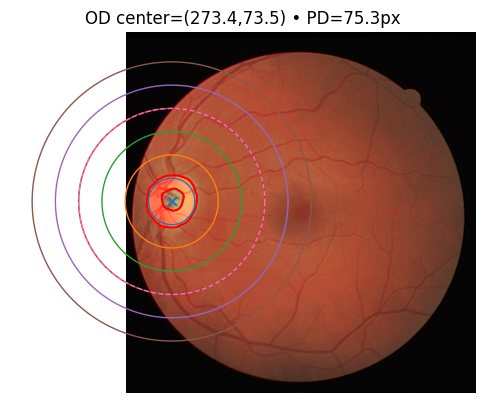

In [24]:
# from your inference:
# rgb            -> the input RGB image
# pred_disc_cup  -> HxW class map from argmax
# model          -> the loaded SegFormer model

rgb=image
id2label = model.config.id2label
disc_id = next((i for i, name in id2label.items() if "disc" in name.lower()), 1)
disc_mask = (pred_disc_cup == disc_id)

# Compute center + PD_px from the disc mask
# (largest component to be safe)
from skimage.measure import label, regionprops
lab = label(disc_mask)
idx = 1 + np.argmax([(lab==i).sum() for i in range(1, lab.max()+1)])
disc_bin = (lab == idx)
props = regionprops(disc_bin.astype(int))[0]
cy, cx = props.centroid
area = float(props.area)
PD_px = 2.0 * (area/np.pi)**0.5

# Visualize
show_disc_overlay(rgb, disc_bin, (cy, cx), PD_px, show_rings=True)